# Hierarhical Clustering

Goal: Use Agglomerative Clustering to generate clusters, using Ward's linkage.

### 1) Load the Cleaned and Scaled Data Set
Because Hierarchical Clustering relies on distance metrics, it is highly sensitive to feature magnitudes. To compensate for this, we will scale the data first.

Save the user_id and is_churned columns for later cluster analysis

In [23]:
import numpy as np
import pandas as pd

data = pd.read_csv("data\processed\spotify_churn_model_matrix.csv")

user_ids = data["user_id"]
is_churned = data["is_churned"]

data = data.drop(columns=["user_id", "is_churned"])
data.head()
#print(is_churned.value_counts())


,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,gender_Female,gender_Male,gender_Other,country_AU,...,country_PK,country_UK,country_US,subscription_type_Family,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Desktop,device_type_Mobile,device_type_Web
0,1.282452,-1.524434,-0.953574,-0.576827,1.766611,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.365956,-0.155555,0.417349,0.229702,-0.509938,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.026522,0.534836,-0.426296,-1.498575,-0.509938,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-1.229408,-1.405401,-1.691763,0.056875,-0.509938,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.679939,1.141904,0.241590,0.344921,-0.509938,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### 2) Create the Linkage and Dendrogram
We will be using Ward's Linkage metric.

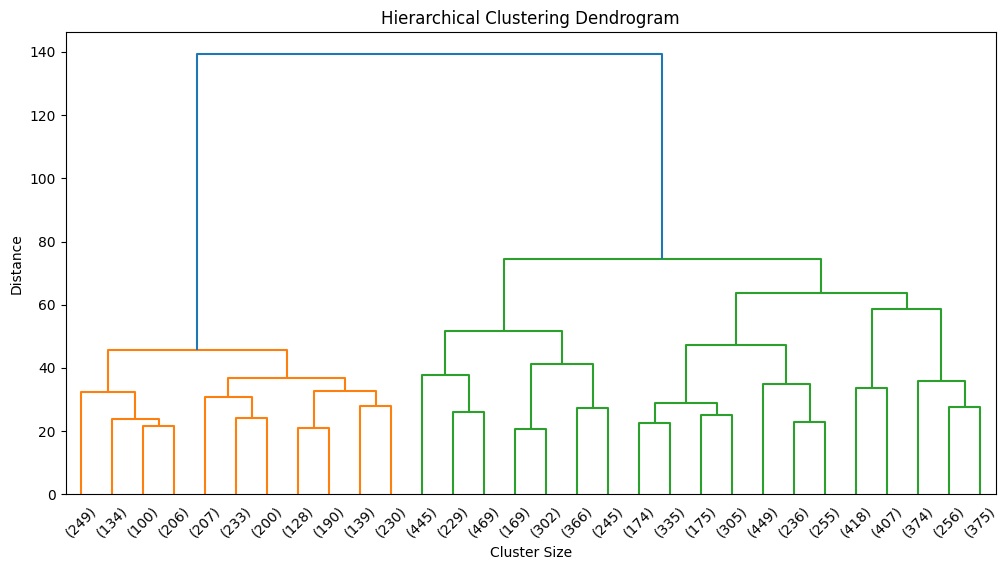

In [24]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

linked_euclidean = linkage(data, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(linked_euclidean, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

### 3) Create the Hierarchical Clustering models

To test the differences, will be trying both Agglomerative Clustering and Divisive Clustering.

In [25]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering_basic = AgglomerativeClustering(linkage='ward')
cluster_labels = agg_clustering_basic.fit_predict(data)
pd.Series(cluster_labels).value_counts()

0    5984
1    2016
Name: count, dtype: int64

Just running the basic Agglomerative Clustering model with no specified number of clusters, we see the model most prominently identifies two clusters, matching very closely to the actual 'is_churned' column:

|Actual Label (is_churned)|Count|-|Cluster Label (Agglomerative)|Count|
|-|-|-|-|-|
|0|5929|-|0|5984|
|1|2071|-|1|2016|

Now lets try to draw out some more complex clusters by testing the silohette score of several models accross a range of specified cluster counts. We will do this via a simple loop to train a model with some number of clusters (n_clusters), compute it's silhouette score, and then print the result.

In [26]:
from sklearn.metrics import silhouette_score
'''
agg_clustering_spec = AgglomerativeClustering(distance_threshold=35.0, n_clusters=None, linkage='ward',)
cluster_labels_spec = agg_clustering_spec.fit_predict(data)
pd.Series(cluster_labels_spec).value_counts()
'''
n_clusters = []
silhouette_scores = []

for n in range(2, 25):
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = model.fit_predict(data)
    score = silhouette_score(data, labels)

    n_clusters.append(n)
    silhouette_scores.append(score)


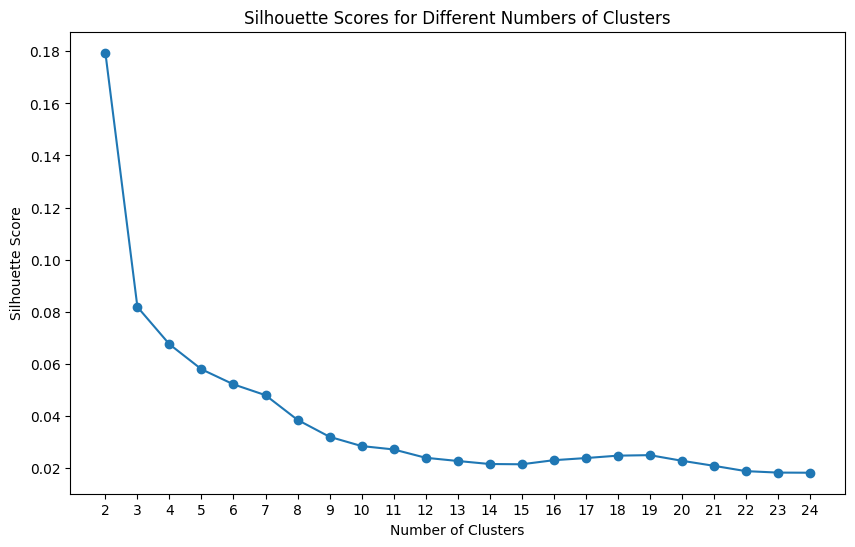

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Numbers of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(n_clusters)
plt.show()

From the Silohouette scores we can see a few things:
- First, the **highest** silohouette score we got was a **0.18 at 2 clusters**, with subsiquent models trending further towards 0, telling us that our **clusters consistantly overlap** even as the number of clusters is limmited to churn results, which is cconsistent with results from our other models.
- When considering models of higher cluster numbers, there seems to be two major jumps in silohouette, first going from 2-3 clusters and the second going from 7-8 clusters, so as the goal of this research is to explore possible hidden clusters, going forward we will consider the **Agglomerative model with n=7 clusters**.

### 4) Churn Analysis using our Agglomerative Clustering Model
Finally, we will now explore churn rates withing our newly discovered clusters.

In [28]:
# Create the final model with the chosen number of clusters
model = AgglomerativeClustering(n_clusters=7, linkage='ward')
new_cluster_labels = model.fit_predict(data)


In [34]:
# Add the new cluster labels, churn status, and user IDs back to the original cleaned DataFrame (not the model matrix)
data_cleaned = pd.read_csv("data\processed\spotify_churn_cleaned.csv")
data_cleaned["cluster"] = new_cluster_labels


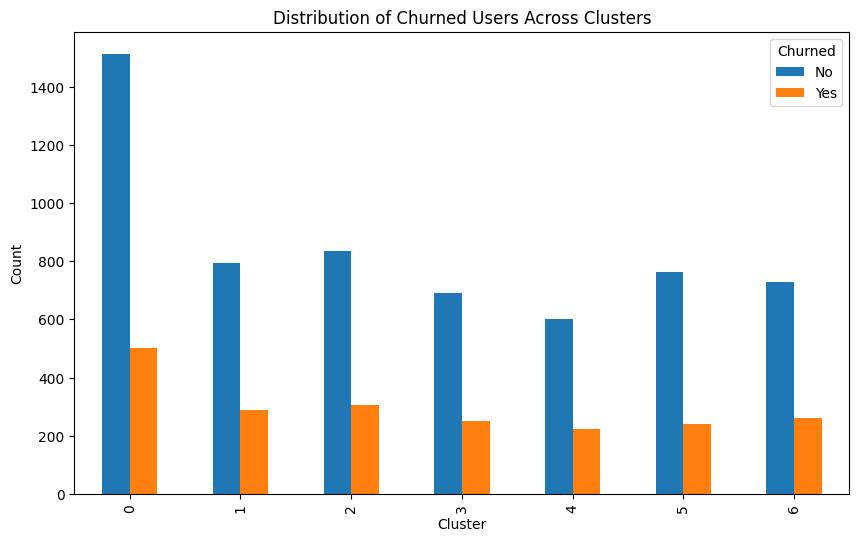

In [35]:
# Analyze the distribution of churned users across clusters
churn_distribution = data_cleaned.groupby("cluster")["is_churned"].value_counts().unstack()
churn_distribution.plot(kind="bar", stacked=False, figsize=(10, 6))
plt.title("Distribution of Churned Users Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

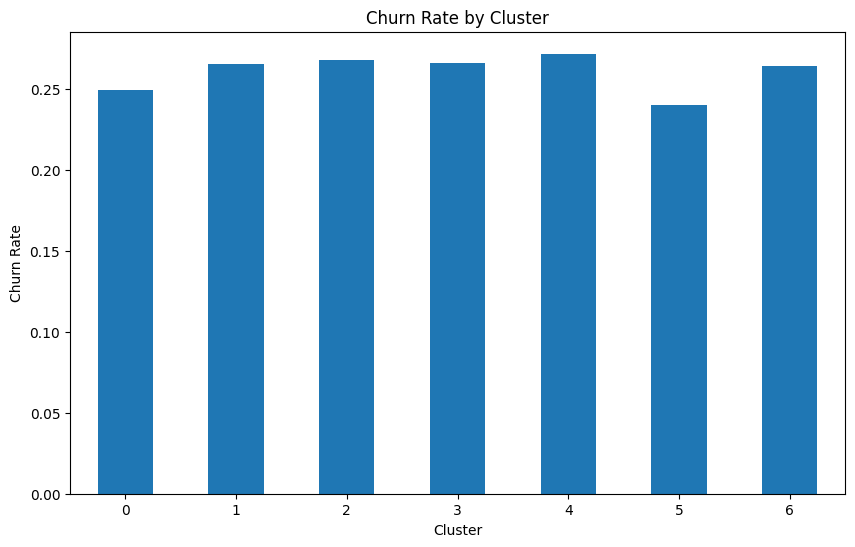

In [36]:
# Analyse the churn rate of each cluster
churn_rate = data_cleaned.groupby("cluster")["is_churned"].mean()
churn_rate.plot(kind="bar", figsize=(10, 6))
plt.title("Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

- Now we can see that churn rate remains relatively consistant across all clusters, which is consistant with our data being very uniformly distributed across our feature space.

In [ ]:

CATEGORICAL_COLS = [
    "gender",
    "country",
    "subscription_type",
    "device_type",
]
NUMERIC_COLS = [
    "age",
    "listening_time",
    "songs_played_per_day",
    "skip_rate",
    "ads_listened_per_week",
]
BINARY_COLS = [
    "offline_listening",
]

stats_num = data_cleaned.groupby("cluster")[NUMERIC_COLS].mean()
stats_cat = data_cleaned.groupby("cluster")[CATEGORICAL_COLS].describe()
stats_binary = data_cleaned.groupby("cluster")[BINARY_COLS].value_counts().unstack()


In [50]:
stats_num

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week
cluster,,,,,
0,37.269345,155.110119,49.168155,0.300719,27.548611
1,28.255083,193.509242,27.608133,0.314510,0.000000
2,26.633421,161.582677,69.653543,0.350201,0.000000
3,45.887234,210.439362,72.490426,0.287500,0.000000
4,36.253333,84.968485,32.991515,0.156594,0.000000
5,47.992040,172.698507,27.584080,0.385682,0.000000
6,44.360971,85.241658,70.099090,0.270111,0.013145


In [51]:
stats_cat

gender                     country                 subscription_type  \
         count unique     top freq   count unique top freq             count   
cluster                                                                        
0         2016      3  Female  687    2016      8  PK  265              2016   
1         1082      3   Other  436    1082      8  DE  169              1082   
2         1143      3   Other  388    1143      8  IN  171              1143   
3          940      3  Female  350     940      8  UK  137               940   
4          825      3    Male  290     825      8  AU  141               825   
5         1005      3  Female  389    1005      8  AU  139              1005   
6          989      3   Other  350     989      8  DE  151               989   

                              device_type                       
        unique      top  freq       count unique      top freq  
cluster                                                         
0            1     Free  2016        2016      3      Web  683  
1            3  Premium   400        1082      3      Web  387  
2            3  Premium   436        1143      3  Desktop  499  
3            3  Premium   385         940      3  Desktop  363  
4            3   Family   343         825      3   Mobile  366  
5            3  Premium   369        1005      3      Web  389  
6            4  Student   405         989      3      Web  368

In [52]:
stats_binary

offline_listening,0,1
cluster,,
0,2016.0,NaN
1,NaN,1082.0
2,NaN,1143.0
3,NaN,940.0
4,NaN,825.0
5,NaN,1005.0
6,2.0,987.0


Observations:
- Cluster 0 has isolated free users, clusters 1-5 are Premium users while Cluster 6 has focused on users with the student plan.
- Categorical features like gender and country seem to stay rather consistant throughout clusters, suggesting that they are largely unimportant for considering churn.
- Cluster 1, which included exclusively free users, had a rather even distribution of devices used whereas every other cluster, which focused on premium account tiers tended to feature one or more device more than others, possibly suggesting a small correlation between Device used and premium plan.
- Listening time and age seemed to show some large variations between clusters, suggesting they may warrent further study for churn.
- Clusters 0, 2, 3, 6 featured elevated songs played per day, while cluster 4 and 6 had significantly lower listening time on average than other clusters

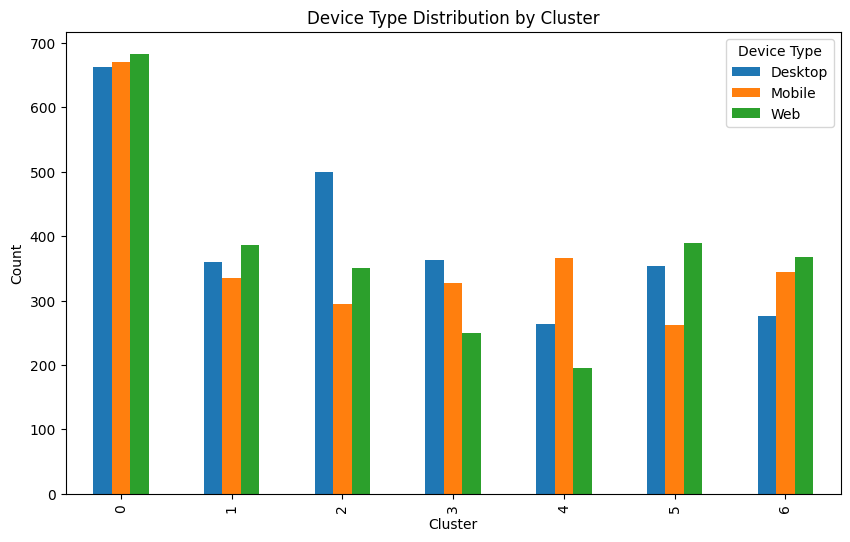

In [53]:
device_stats = data_cleaned.groupby("cluster")["device_type"].value_counts().unstack()
device_stats.plot(kind="bar", stacked=False, figsize=(10, 6))
plt.title("Device Type Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Device Type")
plt.show()

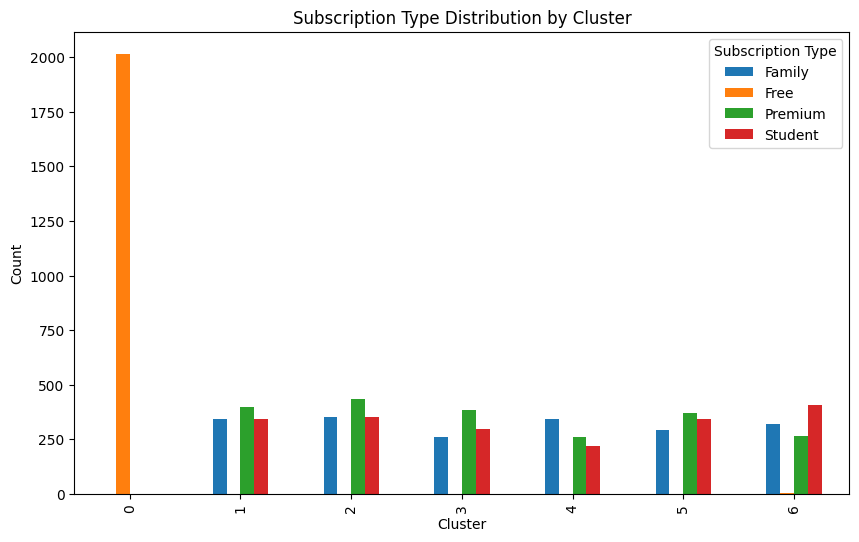

In [54]:
subscription_stats = data_cleaned.groupby("cluster")["subscription_type"].value_counts().unstack()
subscription_stats.plot(kind="bar", stacked=False, figsize=(10, 6))
plt.title("Subscription Type Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Subscription Type")
plt.show()

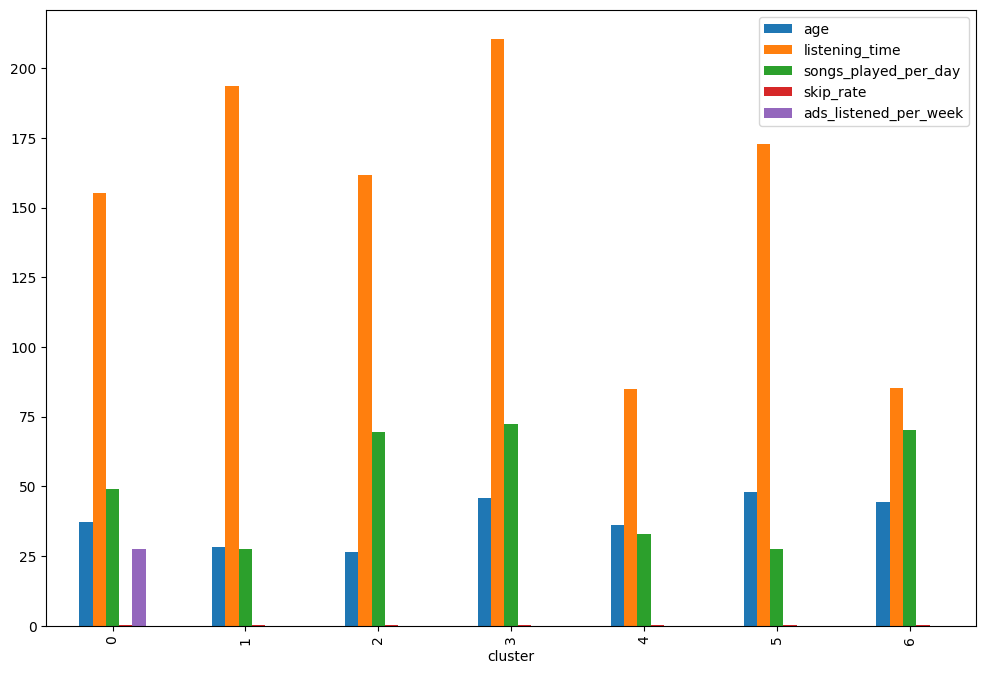

In [57]:
num_stats = data_cleaned.groupby("cluster")[NUMERIC_COLS].mean()
num_stats.plot(kind="bar", figsize=(12, 8))
plt.show()



In [63]:
churn_rate

cluster
0    0.249008
1    0.265250
2    0.267717
3    0.265957
4    0.271515
5    0.239801
6    0.263903
Name: is_churned, dtype: float64

### 5) Final Conclusions

# Hierarchical Clustering Notes

## --- Methodology ---
- Used Aggregative Clustering with Ward's Linkage metric to generate a total of 7 clusters
    - Compared silhouette scores from models ranging from 2-24 clusters, and choosing the model with the most clusters while maintaining reasonable silhouette.
    - Settled on 7 clusters after noticing a sharp jump in silhouette between 7 and 8 clusters.

## --- Results ---
- Silhouette score of 0.048, suggesting high overlap of clusters in feature space.
- Analysis of churn rates within each cluster stayed very consistant, only varying between 23.98% and 27.1%, showing no great risk of churn between clusters.
- Cluster 0 contained exclusively free users, while clusters 1-5 contained only subscribed users, with only cluster 6 featuring both.
- User demographics such as gender, age, and country showed little importance for determening clustering
- 'Listening time' and 'songs played per day'varied largely between clusters, suggesting further study may be warented.
- Cluster 4 seemed to feature unusually low skip rates, while featuring the highest mean mobile users and lowest mean listening time among clusters containing premium users, possibly warrenting further study.


